<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Make                              7385 non-null   bool 
 1   Model                             7385 non-null   bool 
 2   Vehicle Class                     7385 non-null   bool 
 3   Engine Size(L)                    7385 non-null   bool 
 4   Cylinders                         7385 non-null   bool 
 5   Transmission                      7385 non-null   bool 
 6   Fuel Type                         7385 non-null   bool 
 7   Fuel Consumption City (L/100 km)  7385 non-null   bool 
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   bool 
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   bool 
 10  Fuel Consumption Comb (mpg)       7385 non-null   bool 
 11  CO2 Emissions(g/km)               7385 non-null   bool 
dtypes: bool(12)
memory usage: 86.7 KB


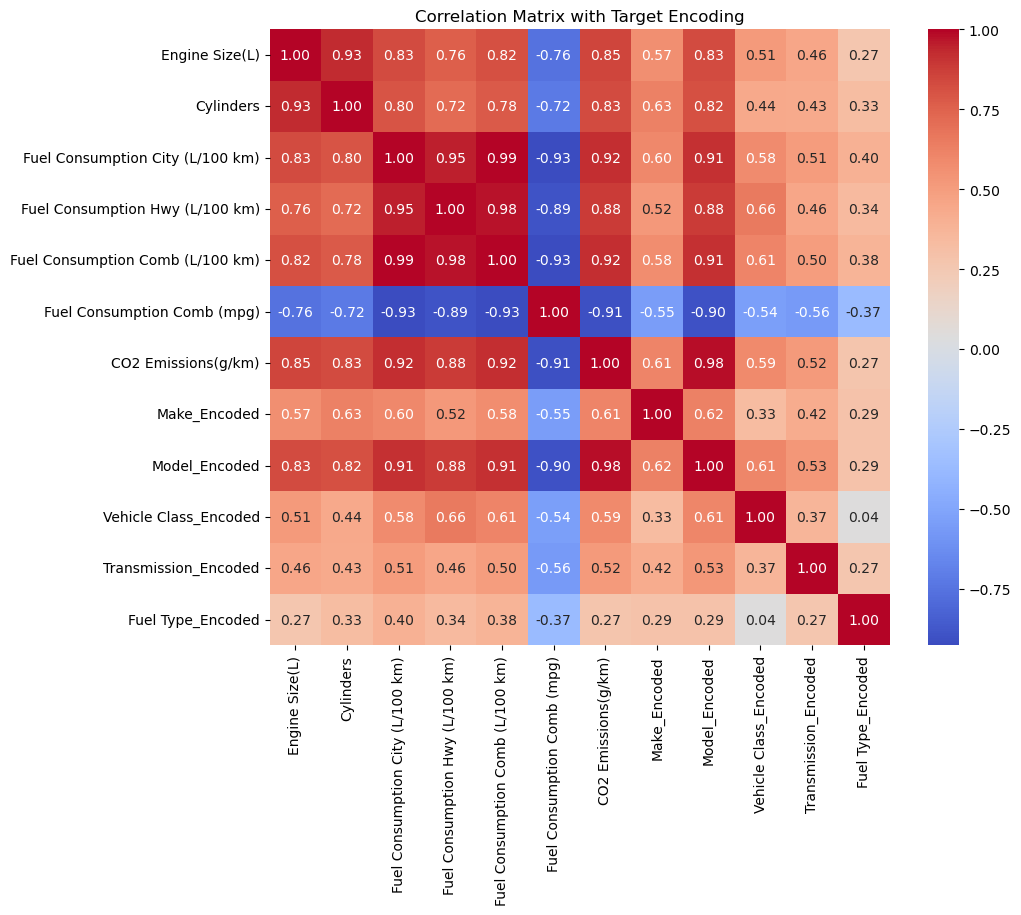

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv(r"C:\Users\user\Downloads\co2.csv")
data.head()
data.isnull().info()
data.describe()
data.info()

target_col = "CO2 Emissions(g/km)"

for col in ["Make", "Model", "Vehicle Class", "Transmission", "Fuel Type"]:
    mean_target = data.groupby(col)[target_col].mean()  
    data[f"{col}_Encoded"] = data[col].map(mean_target)  

data.drop(columns=["Make", "Model", "Vehicle Class", "Transmission", "Fuel Type"], inplace=True)

corr_matrix = data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix with Target Encoding")
plt.show()


In [4]:
df = pd.read_csv(r"C:\Users\user\Downloads\co2.csv")
df.drop(columns=['Fuel Consumption City (L/100 km)', 
                 'Fuel Consumption Hwy (L/100 km)', 
                 'Fuel Consumption Comb (mpg)'], inplace=True)

df = pd.get_dummies(df, columns=['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type'], drop_first=True)



In [5]:
target_column = 'CO2 Emissions(g/km)'

X = df.drop(columns=[target_column])
y = df[target_column]

train_ratio = 0.8
train_size = int(len(df) * train_ratio)

indices = np.random.permutation(len(df))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
Y_train, Y_test = y.iloc[train_indices], y.iloc[test_indices]

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {Y_train.shape}, y_test shape: {Y_test.shape}")


X_train shape: (5908, 2141), X_test shape: (1477, 2141)
y_train shape: (5908,), y_test shape: (1477,)


In [6]:
def normalize_features(X_train, X_test):
    X_train_mean = X_train.mean(axis=0)
    X_train_std = X_train.std(axis=0)

    X_train_std[X_train_std == 0] = 1  

    X_train_normalized = (X_train - X_train_mean) / X_train_std
    X_test_normalized = (X_test - X_train_mean) / X_train_std

    return X_train_normalized, X_test_normalized

X_train_normalized, X_test_normalized = normalize_features(X_train, X_test)

X_train_b = np.c_[np.ones((X_train_normalized.shape[0], 1)), X_train_normalized]
X_test_b = np.c_[np.ones((X_test_normalized.shape[0], 1)), X_test_normalized]

print("Shape of X_train_b:", X_train_b.shape)
print("Shape of X_test_b:", X_test_b.shape)


Shape of X_train_b: (5908, 2142)
Shape of X_test_b: (1477, 2142)


Iteration 0: Train MSE = 66307.0127, Test MSE = 65700.5171
Iteration 1000: Train MSE = 8600.6684, Test MSE = 8706.8263
Iteration 2000: Train MSE = 1203.9871, Test MSE = 1313.9621
Iteration 3000: Train MSE = 202.5817, Test MSE = 306.5905
Iteration 4000: Train MSE = 65.2872, Test MSE = 164.9533
Iteration 5000: Train MSE = 45.3054, Test MSE = 141.9866
Iteration 6000: Train MSE = 41.4944, Test MSE = 135.9131
Iteration 7000: Train MSE = 40.0588, Test MSE = 132.5940
Iteration 8000: Train MSE = 39.0674, Test MSE = 129.9326
Iteration 9000: Train MSE = 38.2221, Test MSE = 127.5511
Iteration 10000: Train MSE = 37.4608, Test MSE = 125.3466
Iteration 11000: Train MSE = 36.7613, Test MSE = 123.2749
Iteration 12000: Train MSE = 36.1111, Test MSE = 121.3106
Iteration 13000: Train MSE = 35.5019, Test MSE = 119.4370
Iteration 14000: Train MSE = 34.9276, Test MSE = 117.6422
Iteration 15000: Train MSE = 34.3834, Test MSE = 115.9173
Iteration 16000: Train MSE = 33.8656, Test MSE = 114.2552
Iteration 17000

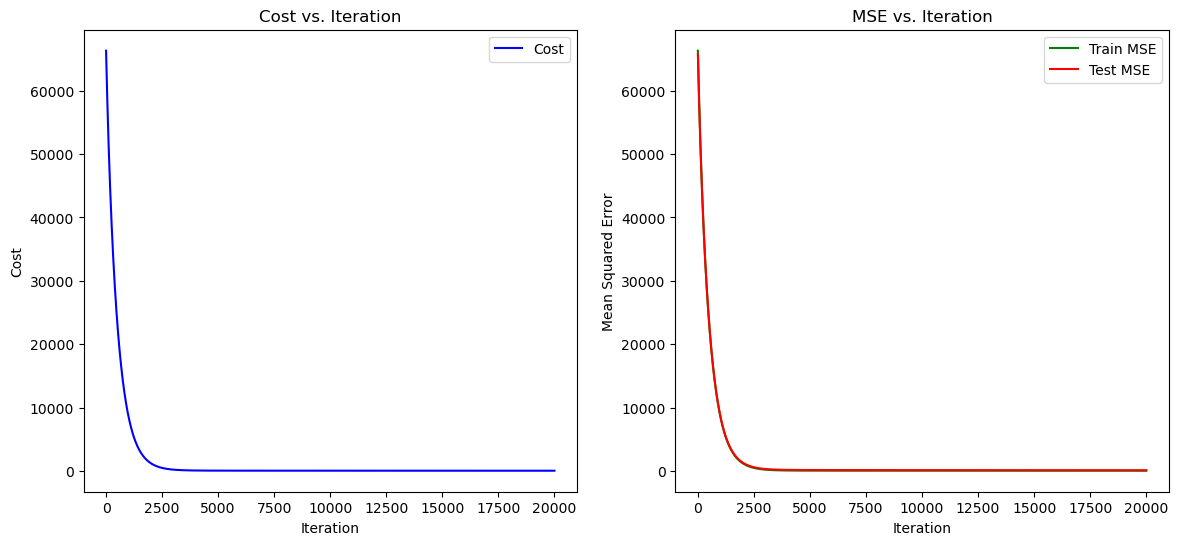

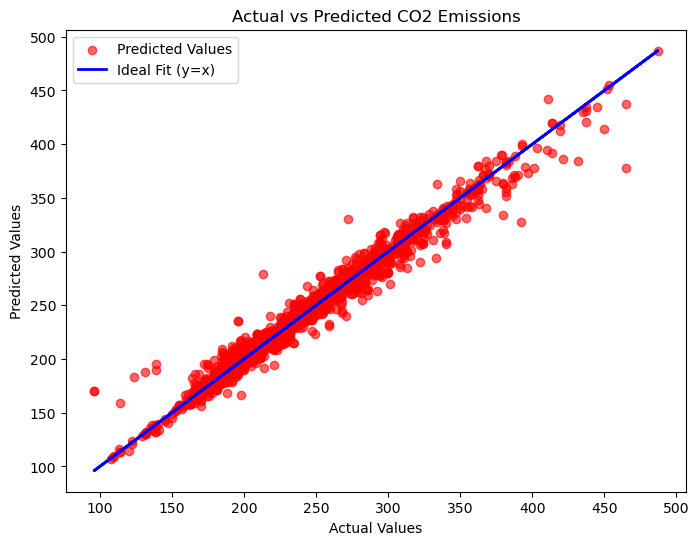

Mean Squared Error (MSE): 108.1395
R-squared (R²): 0.9687


In [11]:
def gradient_descent(X_train, y_train, X_test, y_test, learning_rate=0.001, iterations=20000):
    m, n = X_train.shape
    weights = np.zeros(n)  
    cost_history = []
    train_mse_history = []
    test_mse_history = []

    for i in range(iterations):
        predictions = X_train @ weights  
        errors = predictions - y_train  
        gradients = (1 / m) * (X_train.T @ errors)  
        weights -= learning_rate * gradients 

        train_mse = np.mean(errors ** 2)
        test_mse = np.mean((X_test @ weights - y_test) ** 2)

        cost_history.append(train_mse)
        train_mse_history.append(train_mse)
        test_mse_history.append(test_mse)

        if i % 1000 == 0:
            print(f"Iteration {i}: Train MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}")

    return weights, cost_history, train_mse_history, test_mse_history

learning_rate = 0.001
iterations = 20000
weights, cost_history, train_mse_history, test_mse_history = gradient_descent(
    X_train_b, Y_train, X_test_b, Y_test, learning_rate=learning_rate, iterations=iterations
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(cost_history, label='Cost', color='blue')
plt.title('Cost vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_mse_history, label='Train MSE', color='green')
plt.plot(test_mse_history, label='Test MSE', color='red')
plt.title('MSE vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.legend()

plt.show()

def predict(X, weights):
    return X @ weights

y_test_pred = predict(X_test_b, weights)

plt.figure(figsize=(8, 6))
plt.scatter(Y_test, y_test_pred, color='red', alpha=0.6, label="Predicted Values")
plt.plot(Y_test, Y_test, color='blue', label="Ideal Fit (y=x)", linewidth=2)

plt.title("Actual vs Predicted CO2 Emissions")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()

mse = np.mean((Y_test - y_test_pred) ** 2)
print(f'Mean Squared Error (MSE): {mse:.4f}')

def r2_score(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_residual / ss_total)

r2 = r2_score(Y_test, y_test_pred)
print(f'R-squared (R²): {r2:.4f}')


In [12]:
print(np.var(Y_train))
RMSE = np.sqrt(48)
print(RMSE)  # Easier to interpret
print(df['CO2 Emissions(g/km)'].min())
print(df['CO2 Emissions(g/km)'].max())


3414.8116532888253
6.928203230275509
96
522


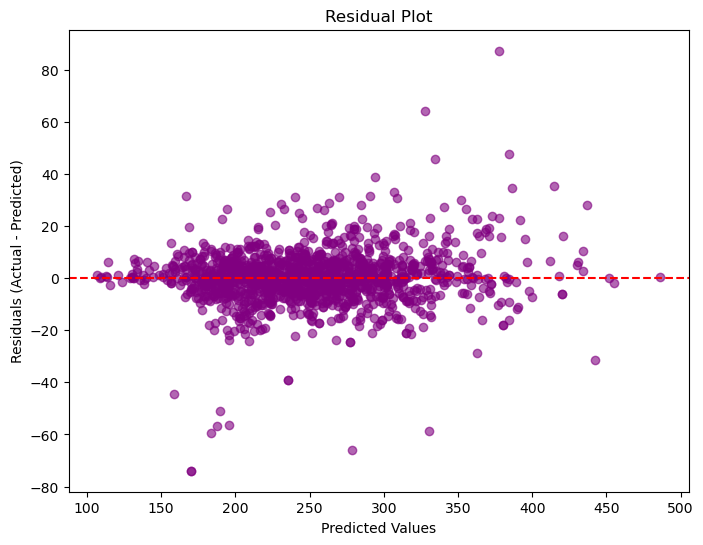

In [13]:
residuals = Y_test - y_test_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, residuals, color="purple", alpha=0.6)
plt.axhline(y=0, color='red', linestyle='dashed')  
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()
